In [ ]:
import numpy as np
import folium
from math import radians, sin, cos, sqrt, atan2
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

# create_data_model and compute_haversine_distance_matrix functions
def create_data_model():
    """Stores the data for the problem with time windows."""
    data = {}
    data['locations'] = [
        (28.6315, 77.2167), (28.6129, 77.2295), (28.6562, 77.2410),
        (28.5245, 77.1855), (28.5535, 77.2588), (28.5933, 77.2507),
        (28.6507, 77.2319), (28.5940, 77.2225), (28.4744, 77.5026),
        (28.5522, 77.1950), (28.7041, 77.1025)
    ]
    data['location_names'] = [ 
        "Depot: Connaught Place", "India Gate", "Red Fort", "Qutub Minar",
        "Lotus Temple", "Humayun's Tomb", "Chandni Chowk", "Khan Market",
        "Akshardham", "Hauz Khas Village", "Rohini"
    ]
    data['demands'] = [0, 1, 1, 2, 4, 2, 4, 8, 8, 1, 2]
    data['vehicle_capacities'] = [15, 15, 15]
    data['num_vehicles'] = len(data['vehicle_capacities'])
    data['depot'] = 0
    data['time_windows'] = [
        (0, 540), (60, 120), (180, 240), (300, 360), (300, 360),
        (120, 180), (180, 240), (60, 120), (240, 300), (360, 420), (0, 120),
    ]
    data['vehicle_speed_kmh'] = 50
    return data

def compute_haversine_distance_matrix(locations):
    num_locations = len(locations)
    distance_matrix = np.zeros((num_locations, num_locations), dtype=int)
    R = 6371000
    for from_node in range(num_locations):
        for to_node in range(num_locations):
            if from_node == to_node: continue
            lat1, lon1 = radians(locations[from_node][0]), radians(locations[from_node][1])
            lat2, lon2 = radians(locations[to_node][0]), radians(locations[to_node][1])
            dlon, dlat = lon2 - lon1, lat2 - lat1
            a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
            c = 2 * atan2(sqrt(a), sqrt(1 - a))
            distance_matrix[from_node][to_node] = int(R * c)
    return distance_matrix

def print_solution(data, manager, routing, solution):
    # This function provides the text summary.
    print(f'Objective: {solution.ObjectiveValue() / 1000:.2f} km')
    time_dimension = routing.GetDimensionOrDie('Time')
    total_distance, total_load, total_time = 0, 0, 0
    
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        plan_output = f'Route for vehicle {vehicle_id}:\n'
        route_distance, route_load = 0, 0
        
        if routing.IsEnd(solution.Value(routing.NextVar(index))):
            plan_output += ' Not used\n'
        else:
            while not routing.IsEnd(index):
                node_index = manager.IndexToNode(index)
                route_load += data['demands'][node_index]
                time_var = time_dimension.CumulVar(index)
                plan_output += (f' {node_index} '
                                f'Load({route_load}) '
                                f'Time({solution.Min(time_var)//60:02d}:{solution.Min(time_var)%60:02d}) -> ')
                previous_index = index
                index = solution.Value(routing.NextVar(index))
                route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)
            time_var = time_dimension.CumulVar(index)
            plan_output += (f'{manager.IndexToNode(index)} '
                            f'Load({route_load}) '
                            f'Time({solution.Min(time_var)//60:02d}:{solution.Min(time_var)%60:02d})\n')
            route_time = solution.Value(time_dimension.CumulVar(index))
            plan_output += f'Distance: {route_distance/1000:.2f}km | Load: {route_load} | Time: {route_time//60}h {route_time%60}m\n'
        
        print(plan_output)
        total_distance += route_distance
        total_load += route_load
        total_time += solution.Value(time_dimension.CumulVar(index)) if not routing.IsEnd(solution.Value(routing.NextVar(routing.Start(vehicle_id)))) else 0
        
    print(f'Total Distance of all routes: {total_distance/1000:.2f}km')
    print(f'Total Load of all routes: {total_load}')

# Function to generate the Folium map
def visualize_solution(data, manager, routing, solution):
    """Generates an interactive map of the solution."""
    # Create map centered on the depot
    m = folium.Map(location=data['locations'][data['depot']], zoom_start=11)

    # Add markers for all locations
    for idx, (loc, name, demand, tw) in enumerate(zip(data['locations'], data['location_names'], data['demands'], data['time_windows'])):
        # Format time window for display (e.g., 8:00 - 17:00)
        start_h, start_m = (tw[0] // 60) + 8, tw[0] % 60
        end_h, end_m = (tw[1] // 60) + 8, tw[1] % 60
        popup_html = f"<b>{name}</b><br>Demand: {demand}<br>Time Window: {start_h:02d}:{start_m:02d} - {end_h:02d}:{end_m:02d}"
        
        if idx == data['depot']:
            folium.Marker(
                loc,
                popup=popup_html,
                icon=folium.Icon(color='black', icon='star')
            ).add_to(m)
        else:
            folium.Marker(
                loc,
                popup=popup_html,
                icon=folium.Icon(color='gray', icon='info-sign')
            ).add_to(m)
    
    # Add route polylines for each vehicle
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        if routing.IsEnd(solution.Value(routing.NextVar(index))):
            continue # Skip unused vehicles
        
        route_coords = []
        route_distance = 0
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route_coords.append(data['locations'][node_index])
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)
        
        # Add the final depot stop to the coordinates
        route_coords.append(data['locations'][data['depot']])
        
        # Create and add the polyline
        line = folium.PolyLine(
            locations=route_coords,
            weight=4,
            color=colors[vehicle_id % len(colors)],
            opacity=0.8
        )
        line.add_child(folium.Tooltip(f"Vehicle {vehicle_id} | Distance: {route_distance / 1000:.2f} km"))
        line.add_to(m)
        
    # Save the map to an HTML file
    m.save('delhi_routes_map_with_time.html')
    print("\nMap has been saved to 'delhi_routes_map_with_time.html'")

# main function is updated to call the new visualization function
def main():
    """Solve the CVRPTW problem and visualize the solution."""
    data = create_data_model()
    distance_matrix = compute_haversine_distance_matrix(data['locations'])
    
    manager = pywrapcp.RoutingIndexManager(len(data['locations']), data['num_vehicles'], data['depot'])
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        return distance_matrix[manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]
    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    def demand_callback(from_index):
        return data['demands'][manager.IndexToNode(from_index)]
    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(demand_callback_index, 0, data['vehicle_capacities'], True, 'Capacity')

    def time_callback(from_index, to_index):
        distance_m = distance_matrix[manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]
        speed_mpm = (data['vehicle_speed_kmh'] * 1000) / 60
        travel_time = int(distance_m / speed_mpm)
        return travel_time + 15

    time_callback_index = routing.RegisterTransitCallback(time_callback)
    routing.AddDimension(
        time_callback_index, 30, 540, False, 'Time')
    time_dimension = routing.GetDimensionOrDie('Time')

    for location_idx, time_window in enumerate(data['time_windows']):
        if location_idx == data['depot']: continue
        index = manager.NodeToIndex(location_idx)
        time_dimension.CumulVar(index).SetRange(time_window[0], time_window[1])

    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        time_dimension.CumulVar(index).SetRange(data['time_windows'][0][0], data['time_windows'][0][1])

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH)
    search_parameters.time_limit.FromSeconds(15)

    solution = routing.SolveWithParameters(search_parameters)
    if solution:
        print_solution(data, manager, routing, solution)
        visualize_solution(data, manager, routing, solution) # [NEW] Call to generate map
    else:
        print('No solution found !')

if __name__ == '__main__':
    main()

Objective: 123.19 km
Route for vehicle 0:
 0 Load(0) Time(00:57) ->  10 Load(2) Time(01:58) ->  2 Load(3) Time(03:00) ->  6 Load(7) Time(03:16) -> 0 Load(7) Time(03:34)
Distance: 31.96km | Load: 7 | Time: 3h 34m

Route for vehicle 1:
 0 Load(0) Time(02:36) ->  8 Load(8) Time(04:00) ->  4 Load(12) Time(05:00) ->  3 Load(14) Time(05:24) ->  9 Load(15) Time(06:00) -> 0 Load(15) Time(06:25)
Distance: 78.47km | Load: 15 | Time: 6h 25m

Route for vehicle 2:
 0 Load(0) Time(00:13) ->  1 Load(1) Time(01:00) ->  7 Load(9) Time(01:17) ->  5 Load(11) Time(02:00) -> 0 Load(11) Time(02:21)
Distance: 12.77km | Load: 11 | Time: 2h 21m

Total Distance of all routes: 123.19km
Total Load of all routes: 33

Map has been saved to 'delhi_routes_map_with_time.html'


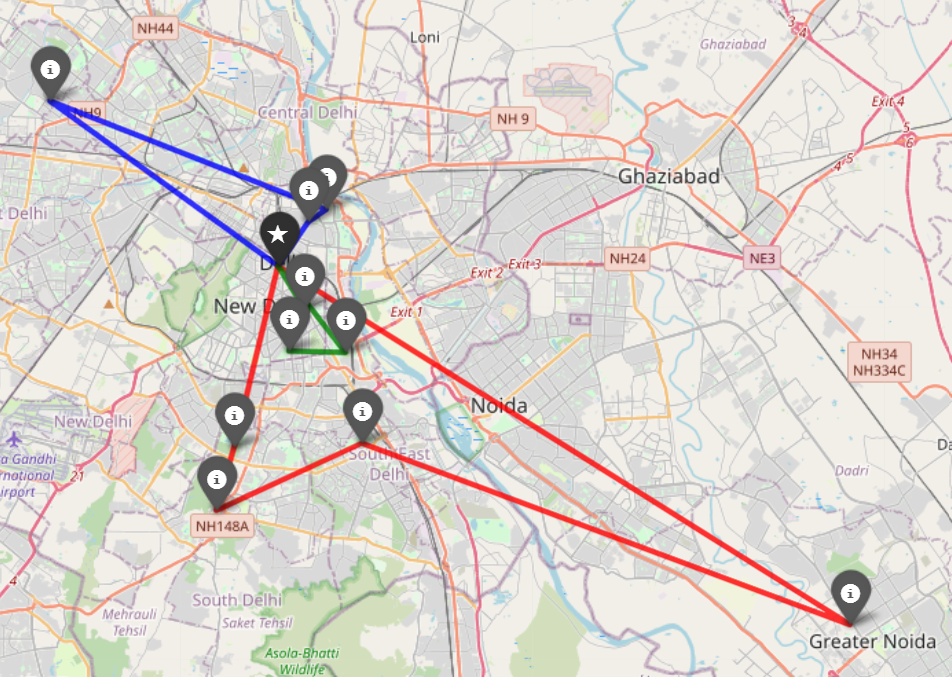